In [11]:
import pandas as pd
import scipy
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import os

In [12]:
long_df = pd.read_csv("../../data/ppss_from_pacs_within_segments_branch_order_summary.csv", sep=',', index_col=0)
long_df

,branch_level,counts,target_cell,probability
type,,,,
end,-10.0,0,SEU-ALLEN_local_182712_15287_15752_5070_CCFv3.swc,0.000000
end,3.0,8,SEU-ALLEN_local_182712_15287_15752_5070_CCFv3.swc,0.009901
end,4.0,9,SEU-ALLEN_local_182712_15287_15752_5070_CCFv3.swc,0.011139
end,5.0,9,SEU-ALLEN_local_182712_15287_15752_5070_CCFv3.swc,0.011139
end,6.0,36,SEU-ALLEN_local_182712_15287_15752_5070_CCFv3.swc,0.044554
...,...,...,...,...
end,4.0,8,SEU-ALLEN_local_192349_8812_6759_7374_CCFv3.swc,0.258065
middle,3.0,4,SEU-ALLEN_local_192349_8812_6759_7374_CCFv3.swc,0.129032
middle,4.0,10,SEU-ALLEN_local_192349_8812_6759_7374_CCFv3.swc,0.322581


In [13]:
pt_df = long_df.pivot_table(index='branch_level', columns=['type'], 
                    values=['probability'], aggfunc='mean')
pt_df.columns = [i[1] for i in pt_df.columns]
pt_df.loc[range(1,11), ['start', 'middle', 'end']]

,start,middle,end
branch_level,,,
1.0,0.050935,0.058079,0.062860
2.0,0.067743,0.080567,0.086253
3.0,0.073635,0.087174,0.094705
4.0,0.075102,0.089049,0.096006
5.0,0.069748,0.083363,0.088851
6.0,0.059666,0.071707,0.077043
7.0,0.048456,0.058629,0.062463
8.0,0.038928,0.047177,0.051591
9.0,0.030173,0.037298,0.040717


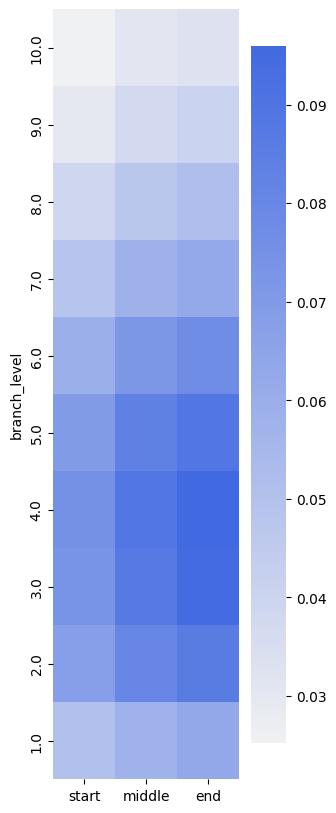

In [14]:
f,ax = plt.subplots(figsize=(3,10))
sns.heatmap(pt_df.loc[range(1,11)[::-1], ['start', 'middle', 'end']],
            cmap=sns.color_palette("light:royalblue", as_cmap=True),)

plt.xlabel("Branch order")
plt.ylabel("%Occurrence")

plt.savefig('./synapse_distribution_within_branch.svg', bbox_inches='tight')

In [15]:
df = long_df.reset_index()

long_df2 = (df.groupby(['target_cell', 'type'], as_index=False)
         .agg({'counts': 'sum', 'probability': 'sum'}))
long_df2

,target_cell,type,counts,probability
0,SEU-ALLEN_local_15257_10008_10862_6996_CCFv3.swc,end,55,0.305556
1,SEU-ALLEN_local_15257_10008_10862_6996_CCFv3.swc,middle,74,0.411111
2,SEU-ALLEN_local_15257_10008_10862_6996_CCFv3.swc,start,51,0.283333
3,SEU-ALLEN_local_15257_10012_10978_7039_CCFv3.swc,end,86,0.348178
4,SEU-ALLEN_local_15257_10012_10978_7039_CCFv3.swc,middle,74,0.299595
...,...,...,...,...
261081,SEU-ALLEN_local_236174_8813_17916_4826_CCFv3.swc,middle,19,0.513514
261082,SEU-ALLEN_local_236174_8813_17916_4826_CCFv3.swc,start,17,0.459459
261083,SEU-ALLEN_local_236174_9571_7846_6146_CCFv3.swc,end,24,0.545455
261084,SEU-ALLEN_local_236174_9571_7846_6146_CCFv3.swc,middle,16,0.363636


In [16]:
long_df2 = long_df2[long_df2['type']!='n']
long_df2

,target_cell,type,counts,probability
0,SEU-ALLEN_local_15257_10008_10862_6996_CCFv3.swc,end,55,0.305556
1,SEU-ALLEN_local_15257_10008_10862_6996_CCFv3.swc,middle,74,0.411111
2,SEU-ALLEN_local_15257_10008_10862_6996_CCFv3.swc,start,51,0.283333
3,SEU-ALLEN_local_15257_10012_10978_7039_CCFv3.swc,end,86,0.348178
4,SEU-ALLEN_local_15257_10012_10978_7039_CCFv3.swc,middle,74,0.299595
...,...,...,...,...
261081,SEU-ALLEN_local_236174_8813_17916_4826_CCFv3.swc,middle,19,0.513514
261082,SEU-ALLEN_local_236174_8813_17916_4826_CCFv3.swc,start,17,0.459459
261083,SEU-ALLEN_local_236174_9571_7846_6146_CCFv3.swc,end,24,0.545455
261084,SEU-ALLEN_local_236174_9571_7846_6146_CCFv3.swc,middle,16,0.363636


C:\Users\yishui\AppData\Local\Temp\ipykernel_40732\3352200478.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=long_df2, x='type', y='probability', fliersize=0, palette = 'tab10')


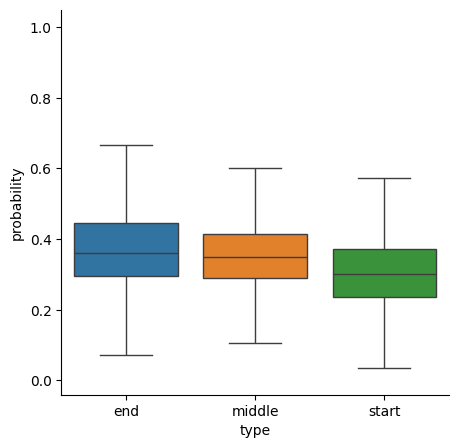

In [17]:
f,ax = plt.subplots(1,1,figsize=(5,5))
sns.boxplot(data=long_df2, x='type', y='probability', fliersize=0, palette = 'tab10')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.ylabel("%PPSSpac(per cell)")

plt.savefig('./synapse_distribution_all_branch.svg', bbox_inches='tight')